In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("NumPy version:", np.__version__)

NumPy version: 2.2.6


In [17]:
# Dataset configuration

NUM_SAMPLES = 6000
SEQ_LENGTH = 20
INPUT_SIZE = 1
OUTPUT_SIZE = 1

# Dataset split
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Reproducibility
SEED = 42

np.random.seed(SEED)

print("Number of samples :", NUM_SAMPLES)
print("Sequence length   :", SEQ_LENGTH)
print("Input size        :", INPUT_SIZE)
print("Output size       :", OUTPUT_SIZE)

Number of samples : 6000
Sequence length   : 20
Input size        : 1
Output size       : 1


In [18]:
def generate_dataset(num_samples, seq_length, seed=42):
    """
    Generate a synthetic sequence classification dataset.

    Each input sequence contains random binary values.
    The target is the first value of the sequence.

    Returns
    -------
    X : ndarray
        Shape: (num_samples, seq_length, 1)

    Y : ndarray
        Shape: (num_samples, 1)
    """
    
    rng = np.random.default_rng(seed)
    
    X = rng.integers(
        low=0,
        high=2,
        size=(num_samples, seq_length, 1)
    ).astype(np.float64)
    
    Y = X[:, 0, :].copy()
    
    return X, Y

In [19]:
X, Y = generate_dataset(
    num_samples=NUM_SAMPLES,
    seq_length=SEQ_LENGTH,
    seed=SEED
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (6000, 20, 1)
Y shape: (6000, 1)


In [20]:
#inspect individual sequence
for i in range(5):
    sequence = X[i, :, 0].astype(int)
    target = int(Y[i, 0])
    
    print(f"Sample {i + 1}")
    print("Sequence:", sequence)
    print("Target  :", target)
    print("First value == target:", sequence[0] == target)
    print("-" * 60)

Sample 1
Sequence: [0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 0]
Target  : 0
First value == target: True
------------------------------------------------------------
Sample 2
Sequence: [1 0 0 1 1 1 0 1 1 0 0 0 0 1 1 0 1 1 0 1]
Target  : 1
First value == target: True
------------------------------------------------------------
Sample 3
Sequence: [0 1 1 0 0 1 0 1 1 1 1 0 0 0 0 0 1 0 1 1]
Target  : 0
First value == target: True
------------------------------------------------------------
Sample 4
Sequence: [1 1 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1]
Target  : 1
First value == target: True
------------------------------------------------------------
Sample 5
Sequence: [1 0 0 1 1 1 0 0 1 1 0 1 1 0 1 0 0 1 1 0]
Target  : 1
First value == target: True
------------------------------------------------------------


In [21]:
# Verify that every target is equal to the first timestep

is_correct = np.all(Y[:, 0] == X[:, 0, 0])

print("Are all targets equal to the first timestep?", is_correct)

Are all targets equal to the first timestep? True


In [22]:
# Check target distribution

num_zeros = np.sum(Y == 0)
num_ones = np.sum(Y == 1)

print("Number of 0 targets:", num_zeros)
print("Number of 1 targets:", num_ones)

print("Percentage of 0 targets:", num_zeros / len(Y) * 100)
print("Percentage of 1 targets:", num_ones / len(Y) * 100)

Number of 0 targets: 2997
Number of 1 targets: 3003
Percentage of 0 targets: 49.95
Percentage of 1 targets: 50.05


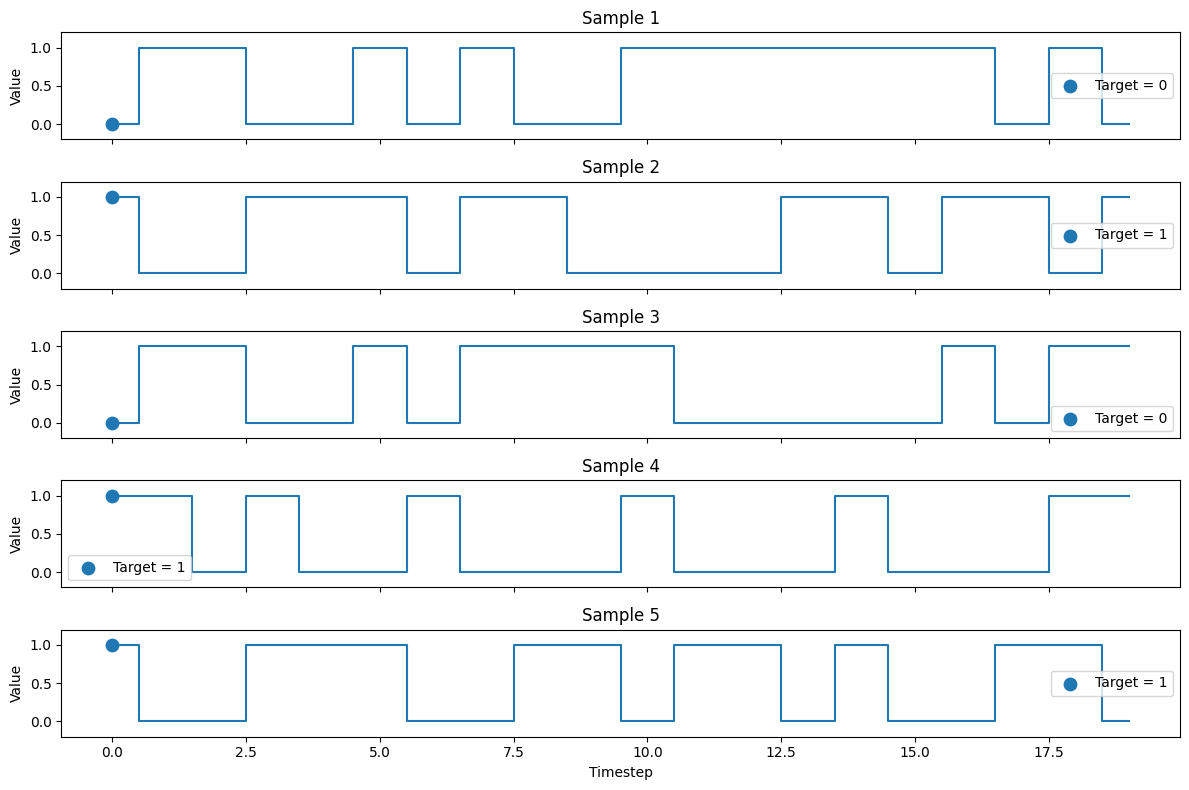

In [23]:
#visualize the sequences
fig, axes = plt.subplots(5, 1, figsize=(12, 8), sharex=True)

for i, ax in enumerate(axes):
    sequence = X[i, :, 0]
    target = Y[i, 0]
    
    ax.step(
        range(SEQ_LENGTH),
        sequence,
        where="mid"
    )
    
    ax.scatter(
        0,
        target,
        s=80,
        label=f"Target = {int(target)}"
    )
    
    ax.set_ylim(-0.2, 1.2)
    ax.set_ylabel("Value")
    ax.set_title(f"Sample {i + 1}")
    ax.legend()

axes[-1].set_xlabel("Timestep")

plt.tight_layout()
plt.show()

In [24]:
def train_val_test_split(X, Y, train_ratio=0.70, val_ratio=0.15, seed=42):
    """
    Shuffle and split the dataset into train, validation and test sets.
    """
    
    rng = np.random.default_rng(seed)
    
    n_samples = len(X)
    
    indices = np.arange(n_samples)
    rng.shuffle(indices)
    
    train_end = int(n_samples * train_ratio)
    val_end = train_end + int(n_samples * val_ratio)
    
    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]
    
    X_train = X[train_idx]
    Y_train = Y[train_idx]
    
    X_val = X[val_idx]
    Y_val = Y[val_idx]
    
    X_test = X[test_idx]
    Y_test = Y[test_idx]
    
    return (
        X_train, Y_train,
        X_val, Y_val,
        X_test, Y_test
    )

In [25]:
(
    X_train, Y_train,
    X_val, Y_val,
    X_test, Y_test
) = train_val_test_split(
    X,
    Y,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    seed=SEED
)

print("Training set   :", X_train.shape, Y_train.shape)
print("Validation set :", X_val.shape, Y_val.shape)
print("Test set       :", X_test.shape, Y_test.shape)

Training set   : (4200, 20, 1) (4200, 1)
Validation set : (900, 20, 1) (900, 1)
Test set       : (900, 20, 1) (900, 1)


In [26]:
# shffl training data/create batches
BATCH_SIZE = 32


def create_batches(X, Y, batch_size, shuffle=True, seed=42):
    
    rng = np.random.default_rng(seed)
    
    n_samples = len(X)
    
    indices = np.arange(n_samples)
    
    if shuffle:
        rng.shuffle(indices)
    
    batches = []
    
    for start in range(0, n_samples, batch_size):
        end = start + batch_size
        
        batch_indices = indices[start:end]
        
        X_batch = X[batch_indices]
        Y_batch = Y[batch_indices]
        
        batches.append((X_batch, Y_batch))
    
    return batches

In [27]:
train_batches = create_batches(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("Number of training batches:", len(train_batches))

X_batch, Y_batch = train_batches[0]

print("First batch X shape:", X_batch.shape)
print("First batch Y shape:", Y_batch.shape)

Number of training batches: 132
First batch X shape: (32, 20, 1)
First batch Y shape: (32, 1)


In [28]:
def to_model_format(X):
    """
    Convert dataset representation:

        (N, T, D)

    into:

        (D, N, T)

    This is a common representation used by from-scratch
    recurrent-network implementations.
    """
    
    return np.transpose(X, (2, 0, 1))


X_train_model = to_model_format(X_train)
X_val_model = to_model_format(X_val)
X_test_model = to_model_format(X_test)

print("Original format :", X_train.shape)
print("Model format    :", X_train_model.shape)

Original format : (4200, 20, 1)
Model format    : (1, 4200, 20)


In [29]:
# Pick one sample and verify that the model-format representation
# contains exactly the same sequence.

sample_index = 0

original_sequence = X_train[sample_index, :, 0]
model_sequence = X_train_model[0, sample_index, :]

print("Original sequence:")
print(original_sequence.astype(int))

print("\nModel-format sequence:")
print(model_sequence.astype(int))

print(
    "\nSequences identical:",
    np.array_equal(original_sequence, model_sequence)
)

Original sequence:
[0 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0]

Model-format sequence:
[0 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0]

Sequences identical: True


In [33]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -50, 50)))


def softmax(x):
    
    x_shifted = x - np.max(x, axis=0, keepdims=True)
    
    exp_x = np.exp(x_shifted)
    
    return exp_x / np.sum(exp_x, axis=0, keepdims=True)

In [34]:
def one_hot_encode(Y, num_classes=2):
    """
    Convert binary labels into one-hot representation.

    Input:
        Y shape = (m, 1)

    Output:
        Y_one_hot shape = (num_classes, m)
    """
    
    Y = Y.astype(int).reshape(-1)
    
    one_hot = np.zeros((num_classes, len(Y)))
    
    one_hot[Y, np.arange(len(Y))] = 1
    
    return one_hot

In [35]:
def compute_loss(y_pred, y_true):
    """
    Cross-entropy loss.

    y_pred:
        shape (n_y, m)

    y_true:
        shape (n_y, m)
    """
    
    m = y_true.shape[1]
    
    y_pred = np.clip(y_pred, 1e-12, 1.0)
    
    loss = -np.sum(y_true * np.log(y_pred)) / m
    
    return loss

# vanilla RNN

In [36]:
def rnn_cell_forward(xt, a_prev, parameters):
    
    Wax = parameters["Wax"]
    Waa = parameters["Waa"]
    Wya = parameters["Wya"]
    ba = parameters["ba"]
    by = parameters["by"]
    
    # Compute next hidden state
    a_next = np.tanh(
        np.dot(Waa, a_prev) +
        np.dot(Wax, xt) +
        ba
    )
    
    # Compute output
    yt_pred = softmax(
        np.dot(Wya, a_next) + by
    )
    
    cache = (
        a_next,
        a_prev,
        xt,
        parameters
    )
    
    return a_next, yt_pred, cache

In [37]:
def rnn_forward(x, a0, parameters):
    
    caches = []
    
    n_x, m, T_x = x.shape
    n_y, n_a = parameters["Wya"].shape
    
    a = np.zeros((n_a, m, T_x))
    y_pred = np.zeros((n_y, m, T_x))
    
    a_next = a0
    
    for t in range(T_x):
        
        a_next, yt_pred, cache = rnn_cell_forward(
            x[:, :, t],
            a_next,
            parameters
        )
        
        a[:, :, t] = a_next
        y_pred[:, :, t] = yt_pred
        
        caches.append(cache)
    
    caches = (caches, x)
    
    return a, y_pred, caches

In [38]:
def rnn_cell_backward(da_next, cache):
    
    (
        a_next,
        a_prev,
        xt,
        parameters
    ) = cache
    
    Wax = parameters["Wax"]
    Waa = parameters["Waa"]
    
    # Derivative through tanh
    dtanh = (1 - a_next ** 2) * da_next
    
    # Gradient with respect to input
    dxt = np.dot(Wax.T, dtanh)
    
    # Gradient with respect to parameters
    dWax = np.dot(dtanh, xt.T)
    dWaa = np.dot(dtanh, a_prev.T)
    
    # Gradient with respect to previous hidden state
    da_prev = np.dot(Waa.T, dtanh)
    
    # Gradient with respect to bias
    dba = np.sum(dtanh, axis=1, keepdims=True)
    
    gradients = {
        "dxt": dxt,
        "da_prev": da_prev,
        "dWax": dWax,
        "dWaa": dWaa,
        "dba": dba
    }
    
    return gradients

In [39]:
def rnn_backward(da, caches):
    
    caches, x = caches
    
    n_a, m, T_x = da.shape
    n_x, m, T_x = x.shape
    
    dx = np.zeros((n_x, m, T_x))
    
    dWax = np.zeros((n_a, n_x))
    dWaa = np.zeros((n_a, n_a))
    dba = np.zeros((n_a, 1))
    
    da_prevt = np.zeros((n_a, m))
    
    for t in reversed(range(T_x)):
        
        gradients = rnn_cell_backward(
            da[:, :, t] + da_prevt,
            caches[t]
        )
        
        dx[:, :, t] = gradients["dxt"]
        
        da_prevt = gradients["da_prev"]
        
        dWax += gradients["dWax"]
        dWaa += gradients["dWaa"]
        dba += gradients["dba"]
    
    da0 = da_prevt
    
    gradients = {
        "dx": dx,
        "da0": da0,
        "dWax": dWax,
        "dWaa": dWaa,
        "dba": dba
    }
    
    return gradients

# LSTM

In [40]:
def lstm_cell_forward(xt, a_prev, c_prev, parameters):
    
    Wf = parameters["Wf"]
    bf = parameters["bf"]
    
    Wi = parameters["Wi"]
    bi = parameters["bi"]
    
    Wc = parameters["Wc"]
    bc = parameters["bc"]
    
    Wo = parameters["Wo"]
    bo = parameters["bo"]
    
    Wy = parameters["Wy"]
    by = parameters["by"]
    
    n_x, m = xt.shape
    
    concat = np.concatenate(
        (a_prev, xt),
        axis=0
    )
    
    # Forget gate
    ft = sigmoid(
        np.dot(Wf, concat) + bf
    )
    
    # Input gate
    it = sigmoid(
        np.dot(Wi, concat) + bi
    )
    
    # Candidate cell state
    cct = np.tanh(
        np.dot(Wc, concat) + bc
    )
    
    # Next cell state
    c_next = (
        ft * c_prev +
        it * cct
    )
    
    # Output gate
    ot = sigmoid(
        np.dot(Wo, concat) + bo
    )
    
    # Next hidden state
    a_next = (
        ot * np.tanh(c_next)
    )
    
    # Prediction
    yt_pred = softmax(
        np.dot(Wy, a_next) + by
    )
    
    cache = (
        a_next,
        c_next,
        a_prev,
        c_prev,
        ft,
        it,
        cct,
        ot,
        xt,
        parameters
    )
    
    return a_next, c_next, yt_pred, cache

In [41]:
def lstm_forward(x, a0, parameters):
    
    caches = []
    
    Wy = parameters["Wy"]
    
    n_x, m, T_x = x.shape
    n_y, n_a = Wy.shape
    
    a = np.zeros((n_a, m, T_x))
    c = np.zeros((n_a, m, T_x))
    y = np.zeros((n_y, m, T_x))
    
    a_next = a0
    c_next = np.zeros((n_a, m))
    
    for t in range(T_x):
        
        xt = x[:, :, t]
        
        a_next, c_next, yt, cache = lstm_cell_forward(
            xt,
            a_next,
            c_next,
            parameters
        )
        
        a[:, :, t] = a_next
        c[:, :, t] = c_next
        y[:, :, t] = yt
        
        caches.append(cache)
    
    caches = (caches, x)
    
    return a, y, c, caches

In [42]:
def lstm_cell_backward(da_next, dc_next, cache):
    
    (
        a_next,
        c_next,
        a_prev,
        c_prev,
        ft,
        it,
        cct,
        ot,
        xt,
        parameters
    ) = cache
    
    Wf = parameters["Wf"]
    Wi = parameters["Wi"]
    Wc = parameters["Wc"]
    Wo = parameters["Wo"]
    
    n_x, m = xt.shape
    n_a, m = a_next.shape
    
    tanh_c = np.tanh(c_next)
    
    # Output gate
    dot = (
        da_next *
        tanh_c *
        ot *
        (1 - ot)
    )
    
    # Total gradient through cell state
    dc_total = (
        dc_next +
        da_next * ot * (1 - tanh_c ** 2)
    )
    
    # Candidate cell state
    dcct = (
        dc_total *
        it *
        (1 - cct ** 2)
    )
    
    # Input gate
    dit = (
        dc_total *
        cct *
        it *
        (1 - it)
    )
    
    # Forget gate
    dft = (
        dc_total *
        c_prev *
        ft *
        (1 - ft)
    )
    
    concat = np.concatenate(
        (a_prev, xt),
        axis=0
    )
    
    # Parameter gradients
    dWf = np.dot(dft, concat.T)
    dWi = np.dot(dit, concat.T)
    dWc = np.dot(dcct, concat.T)
    dWo = np.dot(dot, concat.T)
    
    dbf = np.sum(dft, axis=1, keepdims=True)
    dbi = np.sum(dit, axis=1, keepdims=True)
    dbc = np.sum(dcct, axis=1, keepdims=True)
    dbo = np.sum(dot, axis=1, keepdims=True)
    
    # Gradient through concatenation
    dconcat = (
        np.dot(Wf.T, dft) +
        np.dot(Wi.T, dit) +
        np.dot(Wc.T, dcct) +
        np.dot(Wo.T, dot)
    )
    
    da_prev = dconcat[:n_a, :]
    dxt = dconcat[n_a:, :]
    
    # Previous cell state
    dc_prev = dc_total * ft
    
    gradients = {
        "dxt": dxt,
        "da_prev": da_prev,
        "dc_prev": dc_prev,
        "dWf": dWf,
        "dbf": dbf,
        "dWi": dWi,
        "dbi": dbi,
        "dWc": dWc,
        "dbc": dbc,
        "dWo": dWo,
        "dbo": dbo
    }
    
    return gradients

In [43]:
def lstm_backward(da, caches):
    
    caches, x = caches
    
    n_a, m, T_x = da.shape
    n_x, m, T_x = x.shape
    
    dx = np.zeros((n_x, m, T_x))
    
    da_prevt = np.zeros((n_a, m))
    dc_prevt = np.zeros((n_a, m))
    
    dWf = np.zeros_like(caches[0][9]["Wf"])
    dWi = np.zeros_like(caches[0][9]["Wi"])
    dWc = np.zeros_like(caches[0][9]["Wc"])
    dWo = np.zeros_like(caches[0][9]["Wo"])
    
    dbf = np.zeros((n_a, 1))
    dbi = np.zeros((n_a, 1))
    dbc = np.zeros((n_a, 1))
    dbo = np.zeros((n_a, 1))
    
    for t in reversed(range(T_x)):
        
        gradients = lstm_cell_backward(
            da[:, :, t] + da_prevt,
            dc_prevt,
            caches[t]
        )
        
        dx[:, :, t] = gradients["dxt"]
        
        da_prevt = gradients["da_prev"]
        dc_prevt = gradients["dc_prev"]
        
        dWf += gradients["dWf"]
        dWi += gradients["dWi"]
        dWc += gradients["dWc"]
        dWo += gradients["dWo"]
        
        dbf += gradients["dbf"]
        dbi += gradients["dbi"]
        dbc += gradients["dbc"]
        dbo += gradients["dbo"]
    
    da0 = da_prevt
    
    gradients = {
        "dx": dx,
        "da0": da0,
        "dWf": dWf,
        "dbf": dbf,
        "dWi": dWi,
        "dbi": dbi,
        "dWc": dWc,
        "dbc": dbc,
        "dWo": dWo,
        "dbo": dbo
    }
    
    return gradients

# GRU

In [44]:
def gru_cell_forward(xt, a_prev, parameters):
    
    Wz = parameters["Wz"]
    bz = parameters["bz"]
    
    Wr = parameters["Wr"]
    br = parameters["br"]
    
    Wh = parameters["Wh"]
    bh = parameters["bh"]
    
    Wy = parameters["Wy"]
    by = parameters["by"]
    
    # Concatenate previous hidden state and input
    concat = np.concatenate(
        (a_prev, xt),
        axis=0
    )
    
    # Update gate
    zt = sigmoid(
        np.dot(Wz, concat) + bz
    )
    
    # Reset gate
    rt = sigmoid(
        np.dot(Wr, concat) + br
    )
    
    # Reset hidden state
    reset_hidden = rt * a_prev
    
    concat_candidate = np.concatenate(
        (reset_hidden, xt),
        axis=0
    )
    
    # Candidate hidden state
    a_candidate = np.tanh(
        np.dot(Wh, concat_candidate) + bh
    )
    
    # Next hidden state
    a_next = (
        (1 - zt) * a_prev +
        zt * a_candidate
    )
    
    # Prediction
    yt_pred = softmax(
        np.dot(Wy, a_next) + by
    )
    
    cache = (
        a_next,
        a_prev,
        zt,
        rt,
        a_candidate,
        xt,
        parameters
    )
    
    return a_next, yt_pred, cache

In [45]:
def gru_forward(x, a0, parameters):
    
    caches = []
    
    n_x, m, T_x = x.shape
    n_y, n_a = parameters["Wy"].shape
    
    a = np.zeros((n_a, m, T_x))
    y = np.zeros((n_y, m, T_x))
    
    a_next = a0
    
    for t in range(T_x):
        
        xt = x[:, :, t]
        
        a_next, yt, cache = gru_cell_forward(
            xt,
            a_next,
            parameters
        )
        
        a[:, :, t] = a_next
        y[:, :, t] = yt
        
        caches.append(cache)
    
    caches = (caches, x)
    
    return a, y, caches

In [46]:
def gru_cell_backward(da_next, cache):
    
    (
        a_next,
        a_prev,
        zt,
        rt,
        a_candidate,
        xt,
        parameters
    ) = cache
    
    Wz = parameters["Wz"]
    Wr = parameters["Wr"]
    Wh = parameters["Wh"]
    
    n_a, m = a_prev.shape
    
    # --------------------------------------------------
    # Gradient through:
    #
    # a_next = (1-z) * a_prev + z * a_candidate
    # --------------------------------------------------
    
    da_prev_direct = da_next * (1 - zt)
    
    dzt = da_next * (
        a_candidate - a_prev
    )
    
    da_candidate = da_next * zt
    
    # --------------------------------------------------
    # Candidate hidden state
    # --------------------------------------------------
    
    dtanh = (
        da_candidate *
        (1 - a_candidate ** 2)
    )
    
    reset_hidden = rt * a_prev
    
    concat_candidate = np.concatenate(
        (reset_hidden, xt),
        axis=0
    )
    
    dWh = np.dot(
        dtanh,
        concat_candidate.T
    )
    
    dbh = np.sum(
        dtanh,
        axis=1,
        keepdims=True
    )
    
    dconcat_candidate = np.dot(
        Wh.T,
        dtanh
    )
    
    dreset_hidden = dconcat_candidate[:n_a, :]
    dxt_candidate = dconcat_candidate[n_a:, :]
    
    # --------------------------------------------------
    # Reset gate
    # --------------------------------------------------
    
    drt = dreset_hidden * a_prev
    
    da_prev_from_reset = (
        dreset_hidden * rt
    )
    
    drt_raw = (
        drt *
        rt *
        (1 - rt)
    )
    
    concat = np.concatenate(
        (a_prev, xt),
        axis=0
    )
    
    dWr = np.dot(
        drt_raw,
        concat.T
    )
    
    dbr = np.sum(
        drt_raw,
        axis=1,
        keepdims=True
    )
    
    dconcat_reset = np.dot(
        Wr.T,
        drt_raw
    )
    
    da_prev_from_reset_gate = (
        dconcat_reset[:n_a, :]
    )
    
    dxt_reset_gate = (
        dconcat_reset[n_a:, :]
    )
    
    # --------------------------------------------------
    # Update gate
    # --------------------------------------------------
    
    dzt_raw = (
        dzt *
        zt *
        (1 - zt)
    )
    
    dWz = np.dot(
        dzt_raw,
        concat.T
    )
    
    dbz = np.sum(
        dzt_raw,
        axis=1,
        keepdims=True
    )
    
    dconcat_update = np.dot(
        Wz.T,
        dzt_raw
    )
    
    da_prev_from_update = (
        dconcat_update[:n_a, :]
    )
    
    dxt_update = (
        dconcat_update[n_a:, :]
    )
    
    # --------------------------------------------------
    # Total gradients
    # --------------------------------------------------
    
    da_prev = (
        da_prev_direct +
        da_prev_from_reset +
        da_prev_from_reset_gate +
        da_prev_from_update
    )
    
    dxt = (
        dxt_candidate +
        dxt_reset_gate +
        dxt_update
    )
    
    gradients = {
        "dxt": dxt,
        "da_prev": da_prev,
        "dWz": dWz,
        "dbz": dbz,
        "dWr": dWr,
        "dbr": dbr,
        "dWh": dWh,
        "dbh": dbh
    }
    
    return gradients

In [47]:
def gru_backward(da, caches):
    
    caches, x = caches
    
    n_a, m, T_x = da.shape
    n_x, m, T_x = x.shape
    
    dx = np.zeros((n_x, m, T_x))
    
    da_prevt = np.zeros((n_a, m))
    
    dWz = np.zeros_like(caches[0][6]["Wz"])
    dWr = np.zeros_like(caches[0][6]["Wr"])
    dWh = np.zeros_like(caches[0][6]["Wh"])
    
    dbz = np.zeros((n_a, 1))
    dbr = np.zeros((n_a, 1))
    dbh = np.zeros((n_a, 1))
    
    for t in reversed(range(T_x)):
        
        gradients = gru_cell_backward(
            da[:, :, t] + da_prevt,
            caches[t]
        )
        
        dx[:, :, t] = gradients["dxt"]
        
        da_prevt = gradients["da_prev"]
        
        dWz += gradients["dWz"]
        dWr += gradients["dWr"]
        dWh += gradients["dWh"]
        
        dbz += gradients["dbz"]
        dbr += gradients["dbr"]
        dbh += gradients["dbh"]
    
    da0 = da_prevt
    
    gradients = {
        "dx": dx,
        "da0": da0,
        "dWz": dWz,
        "dbz": dbz,
        "dWr": dWr,
        "dbr": dbr,
        "dWh": dWh,
        "dbh": dbh
    }
    
    return gradients

# parameter initialization

In [48]:
N_A = 32
N_X = INPUT_SIZE
N_Y = 2

LEARNING_RATE = 0.01
EPOCHS = 50

print("Hidden size:", N_A)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)

Hidden size: 32
Learning rate: 0.01
Epochs: 50


In [49]:
def initialize_rnn_parameters(n_x, n_a, n_y, seed=42):
    
    rng = np.random.default_rng(seed)
    
    parameters = {
        "Wax": rng.standard_normal((n_a, n_x)) * 0.1,
        "Waa": rng.standard_normal((n_a, n_a)) * 0.1,
        "Wya": rng.standard_normal((n_y, n_a)) * 0.1,
        "ba": np.zeros((n_a, 1)),
        "by": np.zeros((n_y, 1))
    }
    
    return parameters

In [50]:
def initialize_lstm_parameters(n_x, n_a, n_y, seed=42):
    
    rng = np.random.default_rng(seed)
    
    parameters = {
        "Wf": rng.standard_normal((n_a, n_a + n_x)) * 0.1,
        "bf": np.zeros((n_a, 1)),
        
        "Wi": rng.standard_normal((n_a, n_a + n_x)) * 0.1,
        "bi": np.zeros((n_a, 1)),
        
        "Wc": rng.standard_normal((n_a, n_a + n_x)) * 0.1,
        "bc": np.zeros((n_a, 1)),
        
        "Wo": rng.standard_normal((n_a, n_a + n_x)) * 0.1,
        "bo": np.zeros((n_a, 1)),
        
        "Wy": rng.standard_normal((n_y, n_a)) * 0.1,
        "by": np.zeros((n_y, 1))
    }
    
    return parameters

In [51]:
def initialize_gru_parameters(n_x, n_a, n_y, seed=42):
    
    rng = np.random.default_rng(seed)
    
    parameters = {
        "Wz": rng.standard_normal((n_a, n_a + n_x)) * 0.1,
        "bz": np.zeros((n_a, 1)),
        
        "Wr": rng.standard_normal((n_a, n_a + n_x)) * 0.1,
        "br": np.zeros((n_a, 1)),
        
        "Wh": rng.standard_normal((n_a, n_a + n_x)) * 0.1,
        "bh": np.zeros((n_a, 1)),
        
        "Wy": rng.standard_normal((n_y, n_a)) * 0.1,
        "by": np.zeros((n_y, 1))
    }
    
    return parameters

In [52]:
def clip_gradients(gradients, max_value=5):
    """
    Gradient clipping.

    This prevents extremely large gradients from destabilizing
    the training process.
    """
    
    for key in gradients:
        
        gradients[key] = np.clip(
            gradients[key],
            -max_value,
            max_value
        )
    
    return gradients

In [53]:
def update_parameters(parameters, gradients, learning_rate):
    
    for key in parameters:
        
        gradient_key = "d" + key
        
        if gradient_key in gradients:
            
            parameters[key] -= (
                learning_rate *
                gradients[gradient_key]
            )
    
    return parameters

# RNN model step

In [54]:
def rnn_train_step(X_batch, Y_batch, parameters):
    
    n_x, m, T_x = X_batch.shape
    
    n_a = parameters["Waa"].shape[0]
    
    a0 = np.zeros((n_a, m))
    
    # Forward propagation
    a, y_pred, caches = rnn_forward(
        X_batch,
        a0,
        parameters
    )
    
    # We only use the FINAL timestep
    y_final = y_pred[:, :, -1]
    
    # Convert labels to one-hot
    Y_one_hot = one_hot_encode(
        Y_batch,
        num_classes=2
    )
    
    # Loss
    loss = compute_loss(
        y_final,
        Y_one_hot
    )
    
    # --------------------------------------------------
    # Output layer backward
    # --------------------------------------------------
    
    dz = y_final - Y_one_hot
    
    a_final = a[:, :, -1]
    
    dWya = np.dot(
        dz,
        a_final.T
    ) / m
    
    dby = np.sum(
        dz,
        axis=1,
        keepdims=True
    ) / m
    
    # Gradient flowing into final hidden state
    da_final = np.dot(
        parameters["Wya"].T,
        dz
    )
    
    # Create gradient tensor for all timesteps
    da = np.zeros_like(a)
    
    da[:, :, -1] = da_final
    
    # Backpropagation through time
    gradients = rnn_backward(
        da,
        caches
    )
    
    # Average recurrent gradients
    gradients["dWax"] /= m
    gradients["dWaa"] /= m
    gradients["dba"] /= m
    
    gradients["dWya"] = dWya
    gradients["dby"] = dby
    
    return loss, gradients, y_final

In [55]:
# LSTM Model step
def lstm_train_step(X_batch, Y_batch, parameters):
    
    n_x, m, T_x = X_batch.shape
    
    n_a = parameters["Wf"].shape[0]
    
    a0 = np.zeros((n_a, m))
    
    # Forward
    a, y_pred, c, caches = lstm_forward(
        X_batch,
        a0,
        parameters
    )
    
    # Final timestep
    y_final = y_pred[:, :, -1]
    
    Y_one_hot = one_hot_encode(
        Y_batch,
        num_classes=2
    )
    
    loss = compute_loss(
        y_final,
        Y_one_hot
    )
    
    # Output layer backward
    dz = y_final - Y_one_hot
    
    a_final = a[:, :, -1]
    
    dWy = np.dot(
        dz,
        a_final.T
    ) / m
    
    dby = np.sum(
        dz,
        axis=1,
        keepdims=True
    ) / m
    
    da_final = np.dot(
        parameters["Wy"].T,
        dz
    )
    
    da = np.zeros_like(a)
    
    da[:, :, -1] = da_final
    
    # Backpropagation through time
    gradients = lstm_backward(
        da,
        caches
    )
    
    # Average recurrent gradients
    for key in [
        "dWf", "dbf",
        "dWi", "dbi",
        "dWc", "dbc",
        "dWo", "dbo"
    ]:
        gradients[key] /= m
    
    gradients["dWy"] = dWy
    gradients["dby"] = dby
    
    return loss, gradients, y_final

In [56]:
#gru model step
def gru_train_step(X_batch, Y_batch, parameters):
    
    n_x, m, T_x = X_batch.shape
    
    n_a = parameters["Wz"].shape[0]
    
    a0 = np.zeros((n_a, m))
    
    # Forward
    a, y_pred, caches = gru_forward(
        X_batch,
        a0,
        parameters
    )
    
    # Final timestep
    y_final = y_pred[:, :, -1]
    
    Y_one_hot = one_hot_encode(
        Y_batch,
        num_classes=2
    )
    
    loss = compute_loss(
        y_final,
        Y_one_hot
    )
    
    # Output layer backward
    dz = y_final - Y_one_hot
    
    a_final = a[:, :, -1]
    
    dWy = np.dot(
        dz,
        a_final.T
    ) / m
    
    dby = np.sum(
        dz,
        axis=1,
        keepdims=True
    ) / m
    
    da_final = np.dot(
        parameters["Wy"].T,
        dz
    )
    
    da = np.zeros_like(a)
    
    da[:, :, -1] = da_final
    
    # Backpropagation through time
    gradients = gru_backward(
        da,
        caches
    )
    
    for key in [
        "dWz", "dbz",
        "dWr", "dbr",
        "dWh", "dbh"
    ]:
        gradients[key] /= m
    
    gradients["dWy"] = dWy
    gradients["dby"] = dby
    
    return loss, gradients, y_final

# evaluation

In [57]:
def evaluate_rnn(X, Y, parameters):
    
    n_x, m, T_x = X.shape
    
    n_a = parameters["Waa"].shape[0]
    
    a0 = np.zeros((n_a, m))
    
    a, y_pred, caches = rnn_forward(
        X,
        a0,
        parameters
    )
    
    y_final = y_pred[:, :, -1]
    
    Y_one_hot = one_hot_encode(
        Y,
        num_classes=2
    )
    
    loss = compute_loss(
        y_final,
        Y_one_hot
    )
    
    predictions = np.argmax(
        y_final,
        axis=0
    )
    
    targets = Y.reshape(-1).astype(int)
    
    accuracy = np.mean(
        predictions == targets
    )
    
    return loss, accuracy

In [58]:
def evaluate_lstm(X, Y, parameters):
    
    n_x, m, T_x = X.shape
    
    n_a = parameters["Wf"].shape[0]
    
    a0 = np.zeros((n_a, m))
    
    a, y_pred, c, caches = lstm_forward(
        X,
        a0,
        parameters
    )
    
    y_final = y_pred[:, :, -1]
    
    Y_one_hot = one_hot_encode(
        Y,
        num_classes=2
    )
    
    loss = compute_loss(
        y_final,
        Y_one_hot
    )
    
    predictions = np.argmax(
        y_final,
        axis=0
    )
    
    targets = Y.reshape(-1).astype(int)
    
    accuracy = np.mean(
        predictions == targets
    )
    
    return loss, accuracy

In [59]:
def evaluate_gru(X, Y, parameters):
    
    n_x, m, T_x = X.shape
    
    n_a = parameters["Wz"].shape[0]
    
    a0 = np.zeros((n_a, m))
    
    a, y_pred, caches = gru_forward(
        X,
        a0,
        parameters
    )
    
    y_final = y_pred[:, :, -1]
    
    Y_one_hot = one_hot_encode(
        Y,
        num_classes=2
    )
    
    loss = compute_loss(
        y_final,
        Y_one_hot
    )
    
    predictions = np.argmax(
        y_final,
        axis=0
    )
    
    targets = Y.reshape(-1).astype(int)
    
    accuracy = np.mean(
        predictions == targets
    )
    
    return loss, accuracy

# training loop

In [60]:
def train_rnn(
    X_train,
    Y_train,
    X_val,
    Y_val,
    n_x,
    n_a,
    n_y,
    epochs,
    batch_size,
    learning_rate,
    seed=42
):
    
    parameters = initialize_rnn_parameters(
        n_x,
        n_a,
        n_y,
        seed=seed
    )
    
    train_losses = []
    val_losses = []
    
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
        
        batches = create_batches(
            X_train,
            Y_train,
            batch_size=batch_size,
            shuffle=True,
            seed=seed + epoch
        )
        
        epoch_loss = 0
        
        for X_batch_original, Y_batch in batches:
            
            X_batch = to_model_format(
                X_batch_original
            )
            
            loss, gradients, _ = rnn_train_step(
                X_batch,
                Y_batch,
                parameters
            )
            
            gradients = clip_gradients(
                gradients,
                max_value=5
            )
            
            parameters = update_parameters(
                parameters,
                gradients,
                learning_rate
            )
            
            epoch_loss += loss * len(Y_batch)
        
        epoch_loss /= len(X_train)
        
        X_train_model = to_model_format(X_train)
        X_val_model = to_model_format(X_val)
        
        train_loss, train_acc = evaluate_rnn(
            X_train_model,
            Y_train,
            parameters
        )
        
        val_loss, val_acc = evaluate_rnn(
            X_val_model,
            Y_val,
            parameters
        )
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            
            print(
                f"Epoch {epoch + 1:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )
    
    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_accuracy": train_accuracies,
        "val_accuracy": val_accuracies
    }
    
    return parameters, history

In [61]:
rnn_parameters, rnn_history = train_rnn(
    X_train=X_train,
    Y_train=Y_train,
    X_val=X_val,
    Y_val=Y_val,
    n_x=N_X,
    n_a=N_A,
    n_y=N_Y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=42
)

Epoch   1/50 | Train Loss: 0.6934 | Val Loss: 0.6939 | Train Acc: 0.4943 | Val Acc: 0.4822
Epoch   5/50 | Train Loss: 0.6931 | Val Loss: 0.6945 | Train Acc: 0.5064 | Val Acc: 0.4744
Epoch  10/50 | Train Loss: 0.6929 | Val Loss: 0.6948 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  15/50 | Train Loss: 0.6928 | Val Loss: 0.6945 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  20/50 | Train Loss: 0.6928 | Val Loss: 0.6949 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  25/50 | Train Loss: 0.6927 | Val Loss: 0.6948 | Train Acc: 0.5102 | Val Acc: 0.4656
Epoch  30/50 | Train Loss: 0.6927 | Val Loss: 0.6946 | Train Acc: 0.5105 | Val Acc: 0.4811
Epoch  35/50 | Train Loss: 0.6927 | Val Loss: 0.6947 | Train Acc: 0.5110 | Val Acc: 0.4900
Epoch  40/50 | Train Loss: 0.6927 | Val Loss: 0.6949 | Train Acc: 0.5119 | Val Acc: 0.4900
Epoch  45/50 | Train Loss: 0.6926 | Val Loss: 0.6945 | Train Acc: 0.5119 | Val Acc: 0.4900
Epoch  50/50 | Train Loss: 0.6926 | Val Loss: 0.6943 | Train Acc: 0.5114 | Val Acc: 0.4933

In [62]:
def train_lstm(
    X_train,
    Y_train,
    X_val,
    Y_val,
    n_x,
    n_a,
    n_y,
    epochs,
    batch_size,
    learning_rate,
    seed=42
):
    
    parameters = initialize_lstm_parameters(
        n_x,
        n_a,
        n_y,
        seed=seed
    )
    
    train_losses = []
    val_losses = []
    
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
        
        batches = create_batches(
            X_train,
            Y_train,
            batch_size=batch_size,
            shuffle=True,
            seed=seed + epoch
        )
        
        for X_batch_original, Y_batch in batches:
            
            X_batch = to_model_format(
                X_batch_original
            )
            
            loss, gradients, _ = lstm_train_step(
                X_batch,
                Y_batch,
                parameters
            )
            
            gradients = clip_gradients(
                gradients,
                max_value=5
            )
            
            parameters = update_parameters(
                parameters,
                gradients,
                learning_rate
            )
        
        X_train_model = to_model_format(X_train)
        X_val_model = to_model_format(X_val)
        
        train_loss, train_acc = evaluate_lstm(
            X_train_model,
            Y_train,
            parameters
        )
        
        val_loss, val_acc = evaluate_lstm(
            X_val_model,
            Y_val,
            parameters
        )
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            
            print(
                f"Epoch {epoch + 1:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )
    
    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_accuracy": train_accuracies,
        "val_accuracy": val_accuracies
    }
    
    return parameters, history

In [63]:
lstm_parameters, lstm_history = train_lstm(
    X_train=X_train,
    Y_train=Y_train,
    X_val=X_val,
    Y_val=Y_val,
    n_x=N_X,
    n_a=N_A,
    n_y=N_Y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=42
)

Epoch   1/50 | Train Loss: 0.6931 | Val Loss: 0.6937 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch   5/50 | Train Loss: 0.6930 | Val Loss: 0.6941 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  10/50 | Train Loss: 0.6930 | Val Loss: 0.6945 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  15/50 | Train Loss: 0.6930 | Val Loss: 0.6943 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  20/50 | Train Loss: 0.6929 | Val Loss: 0.6946 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  25/50 | Train Loss: 0.6929 | Val Loss: 0.6945 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  30/50 | Train Loss: 0.6929 | Val Loss: 0.6944 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  35/50 | Train Loss: 0.6929 | Val Loss: 0.6945 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  40/50 | Train Loss: 0.6929 | Val Loss: 0.6946 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  45/50 | Train Loss: 0.6929 | Val Loss: 0.6942 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  50/50 | Train Loss: 0.6929 | Val Loss: 0.6940 | Train Acc: 0.5102 | Val Acc: 0.4722

In [64]:
def train_gru(
    X_train,
    Y_train,
    X_val,
    Y_val,
    n_x,
    n_a,
    n_y,
    epochs,
    batch_size,
    learning_rate,
    seed=42
):
    
    parameters = initialize_gru_parameters(
        n_x,
        n_a,
        n_y,
        seed=seed
    )
    
    train_losses = []
    val_losses = []
    
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
        
        batches = create_batches(
            X_train,
            Y_train,
            batch_size=batch_size,
            shuffle=True,
            seed=seed + epoch
        )
        
        for X_batch_original, Y_batch in batches:
            
            X_batch = to_model_format(
                X_batch_original
            )
            
            loss, gradients, _ = gru_train_step(
                X_batch,
                Y_batch,
                parameters
            )
            
            gradients = clip_gradients(
                gradients,
                max_value=5
            )
            
            parameters = update_parameters(
                parameters,
                gradients,
                learning_rate
            )
        
        X_train_model = to_model_format(X_train)
        X_val_model = to_model_format(X_val)
        
        train_loss, train_acc = evaluate_gru(
            X_train_model,
            Y_train,
            parameters
        )
        
        val_loss, val_acc = evaluate_gru(
            X_val_model,
            Y_val,
            parameters
        )
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            
            print(
                f"Epoch {epoch + 1:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )
    
    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_accuracy": train_accuracies,
        "val_accuracy": val_accuracies
    }
    
    return parameters, history

In [65]:
gru_parameters, gru_history = train_gru(
    X_train=X_train,
    Y_train=Y_train,
    X_val=X_val,
    Y_val=Y_val,
    n_x=N_X,
    n_a=N_A,
    n_y=N_Y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=42
)

Epoch   1/50 | Train Loss: 0.6931 | Val Loss: 0.6939 | Train Acc: 0.5076 | Val Acc: 0.4667
Epoch   5/50 | Train Loss: 0.6930 | Val Loss: 0.6941 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  10/50 | Train Loss: 0.6929 | Val Loss: 0.6946 | Train Acc: 0.5086 | Val Acc: 0.4656
Epoch  15/50 | Train Loss: 0.6929 | Val Loss: 0.6942 | Train Acc: 0.5102 | Val Acc: 0.4711
Epoch  20/50 | Train Loss: 0.6928 | Val Loss: 0.6947 | Train Acc: 0.5095 | Val Acc: 0.4656
Epoch  25/50 | Train Loss: 0.6928 | Val Loss: 0.6945 | Train Acc: 0.5086 | Val Acc: 0.4789
Epoch  30/50 | Train Loss: 0.6928 | Val Loss: 0.6943 | Train Acc: 0.5095 | Val Acc: 0.4867
Epoch  35/50 | Train Loss: 0.6928 | Val Loss: 0.6944 | Train Acc: 0.5074 | Val Acc: 0.4889
Epoch  40/50 | Train Loss: 0.6928 | Val Loss: 0.6946 | Train Acc: 0.5095 | Val Acc: 0.4867
Epoch  45/50 | Train Loss: 0.6928 | Val Loss: 0.6941 | Train Acc: 0.5081 | Val Acc: 0.4822
Epoch  50/50 | Train Loss: 0.6928 | Val Loss: 0.6938 | Train Acc: 0.5062 | Val Acc: 0.4911

# plot training results

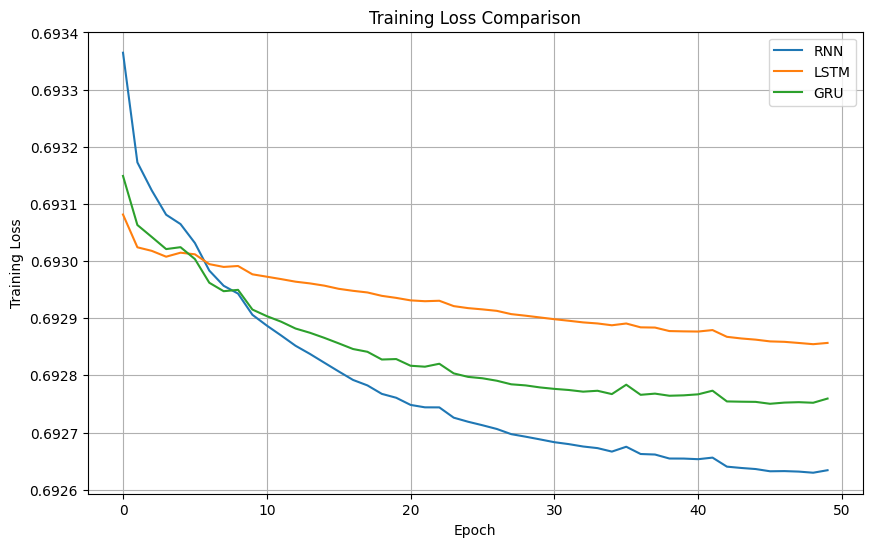

In [66]:
plt.figure(figsize=(10, 6))

plt.plot(
    rnn_history["train_loss"],
    label="RNN"
)

plt.plot(
    lstm_history["train_loss"],
    label="LSTM"
)

plt.plot(
    gru_history["train_loss"],
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")

plt.legend()
plt.grid(True)

plt.show()

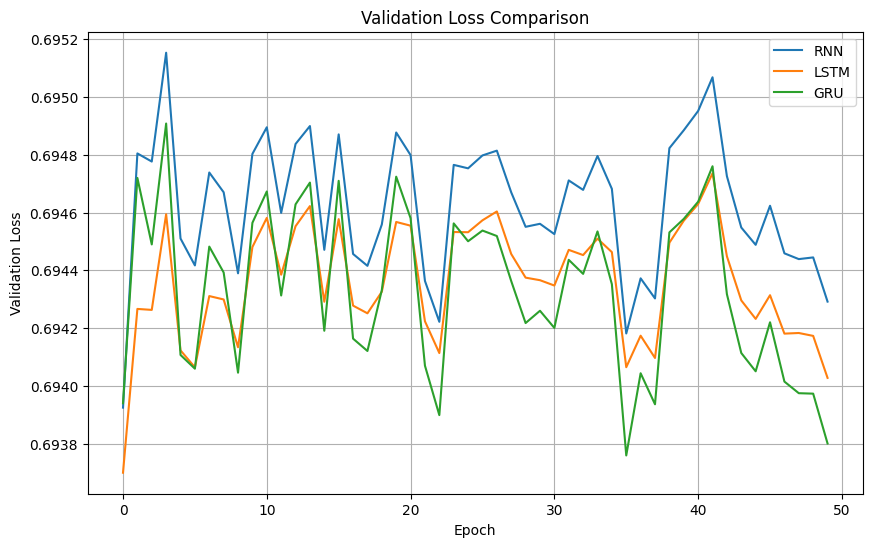

In [67]:
plt.figure(figsize=(10, 6))

plt.plot(
    rnn_history["val_loss"],
    label="RNN"
)

plt.plot(
    lstm_history["val_loss"],
    label="LSTM"
)

plt.plot(
    gru_history["val_loss"],
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")

plt.legend()
plt.grid(True)

plt.show()

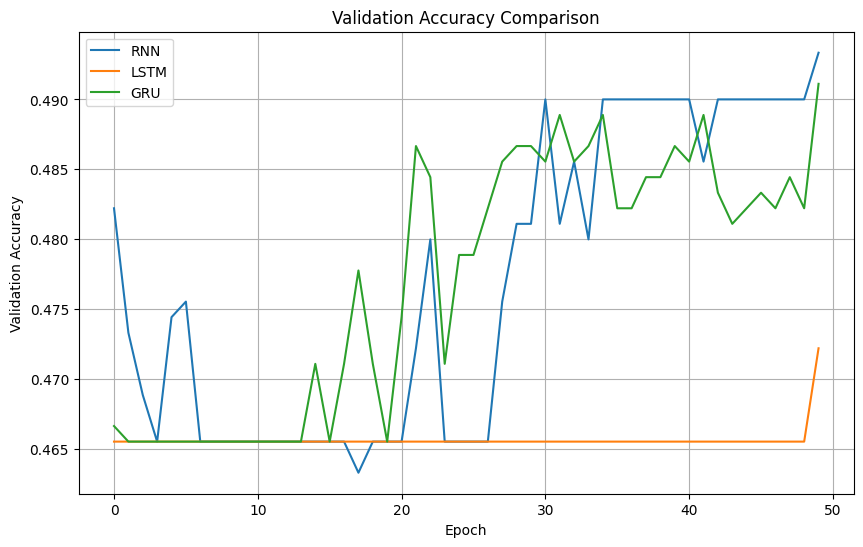

In [68]:
plt.figure(figsize=(10, 6))

plt.plot(
    rnn_history["val_accuracy"],
    label="RNN"
)

plt.plot(
    lstm_history["val_accuracy"],
    label="LSTM"
)

plt.plot(
    gru_history["val_accuracy"],
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")

plt.legend()
plt.grid(True)

plt.show()

# evaluation

In [69]:
X_test_model = to_model_format(X_test)

rnn_test_loss, rnn_test_acc = evaluate_rnn(
    X_test_model,
    Y_test,
    rnn_parameters
)

lstm_test_loss, lstm_test_acc = evaluate_lstm(
    X_test_model,
    Y_test,
    lstm_parameters
)

gru_test_loss, gru_test_acc = evaluate_gru(
    X_test_model,
    Y_test,
    gru_parameters
)

print("=" * 60)
print("STAGE 2 TEST RESULTS")
print("=" * 60)

print(
    f"RNN  | Loss: {rnn_test_loss:.4f} | "
    f"Accuracy: {rnn_test_acc:.4f}"
)

print(
    f"LSTM | Loss: {lstm_test_loss:.4f} | "
    f"Accuracy: {lstm_test_acc:.4f}"
)

print(
    f"GRU  | Loss: {gru_test_loss:.4f} | "
    f"Accuracy: {gru_test_acc:.4f}"
)

print("=" * 60)

STAGE 2 TEST RESULTS
RNN  | Loss: 0.6937 | Accuracy: 0.4833
LSTM | Loss: 0.6937 | Accuracy: 0.4922
GRU  | Loss: 0.6940 | Accuracy: 0.4811


In [70]:
def show_predictions(X, Y, rnn_parameters, lstm_parameters, gru_parameters, num_samples=10):
    
    X_model = to_model_format(X[:num_samples])
    
    # RNN
    n_a_rnn = rnn_parameters["Waa"].shape[0]
    a0_rnn = np.zeros((n_a_rnn, num_samples))
    
    _, rnn_y, _ = rnn_forward(
        X_model,
        a0_rnn,
        rnn_parameters
    )
    
    rnn_final = rnn_y[:, :, -1]
    rnn_pred = np.argmax(rnn_final, axis=0)
    
    # LSTM
    n_a_lstm = lstm_parameters["Wf"].shape[0]
    a0_lstm = np.zeros((n_a_lstm, num_samples))
    
    _, lstm_y, _, _ = lstm_forward(
        X_model,
        a0_lstm,
        lstm_parameters
    )
    
    lstm_final = lstm_y[:, :, -1]
    lstm_pred = np.argmax(lstm_final, axis=0)
    
    # GRU
    n_a_gru = gru_parameters["Wz"].shape[0]
    a0_gru = np.zeros((n_a_gru, num_samples))
    
    _, gru_y, _ = gru_forward(
        X_model,
        a0_gru,
        gru_parameters
    )
    
    gru_final = gru_y[:, :, -1]
    gru_pred = np.argmax(gru_final, axis=0)
    
    print(
        f"{'Sample':<10}"
        f"{'Target':<10}"
        f"{'RNN':<10}"
        f"{'LSTM':<10}"
        f"{'GRU':<10}"
    )
    
    print("-" * 50)
    
    for i in range(num_samples):
        
        print(
            f"{i:<10}"
            f"{int(Y[i, 0]):<10}"
            f"{rnn_pred[i]:<10}"
            f"{lstm_pred[i]:<10}"
            f"{gru_pred[i]:<10}"
        )

In [71]:
show_predictions(
    X_test,
    Y_test,
    rnn_parameters,
    lstm_parameters,
    gru_parameters,
    num_samples=10
)

Sample    Target    RNN       LSTM      GRU       
--------------------------------------------------
0         0         0         0         0         
1         1         0         0         0         
2         1         1         0         1         
3         0         0         0         0         
4         0         0         0         0         
5         0         0         0         0         
6         1         1         0         1         
7         1         0         0         0         
8         0         0         0         0         
9         0         0         0         0         


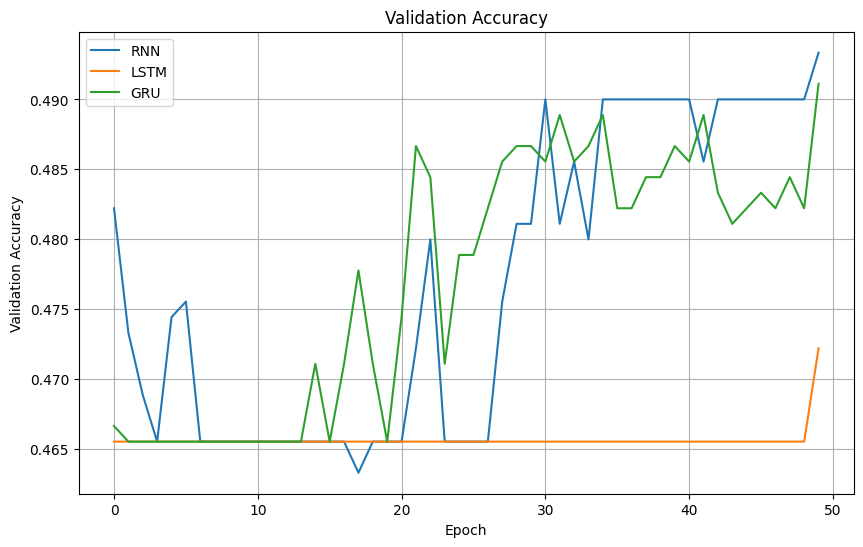

In [73]:
plt.figure(figsize=(10, 6))

plt.plot(
    rnn_history["val_accuracy"],
    label="RNN"
)

plt.plot(
    lstm_history["val_accuracy"],
    label="LSTM"
)

plt.plot(
    gru_history["val_accuracy"],
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [74]:
def count_parameters(parameters):
    total = 0
    
    for key, value in parameters.items():
        total += value.size
    
    return total


rnn_params = count_parameters(rnn_parameters)
lstm_params = count_parameters(lstm_parameters)
gru_params = count_parameters(gru_parameters)

print("Number of parameters")
print("-" * 40)
print(f"RNN  : {rnn_params:,}")
print(f"LSTM : {lstm_params:,}")
print(f"GRU  : {gru_params:,}")

Number of parameters
----------------------------------------
RNN  : 1,154
LSTM : 4,418
GRU  : 3,330


In [75]:
def get_model_probabilities(X, parameters, model_type):
    
    X_model = to_model_format(X)
    
    m = X.shape[0]
    
    if model_type == "RNN":
        
        n_a = parameters["Waa"].shape[0]
        a0 = np.zeros((n_a, m))
        
        _, y, _ = rnn_forward(
            X_model,
            a0,
            parameters
        )
        
    elif model_type == "LSTM":
        
        n_a = parameters["Wf"].shape[0]
        a0 = np.zeros((n_a, m))
        
        _, y, _, _ = lstm_forward(
            X_model,
            a0,
            parameters
        )
        
    elif model_type == "GRU":
        
        n_a = parameters["Wz"].shape[0]
        a0 = np.zeros((n_a, m))
        
        _, y, _ = gru_forward(
            X_model,
            a0,
            parameters
        )
    
    return y[:, :, -1]

In [76]:
num_samples = 20

X_sample = X_test[:num_samples]
Y_sample = Y_test[:num_samples]

rnn_probs = get_model_probabilities(
    X_sample,
    rnn_parameters,
    "RNN"
)

lstm_probs = get_model_probabilities(
    X_sample,
    lstm_parameters,
    "LSTM"
)

gru_probs = get_model_probabilities(
    X_sample,
    gru_parameters,
    "GRU"
)

print("Sample | Target | RNN P(1) | LSTM P(1) | GRU P(1)")
print("-" * 55)

for i in range(num_samples):
    
    print(
        f"{i:6d} | "
        f"{int(Y_sample[i, 0]):6d} | "
        f"{rnn_probs[1, i]:8.4f} | "
        f"{lstm_probs[1, i]:9.4f} | "
        f"{gru_probs[1, i]:8.4f}"
    )

Sample | Target | RNN P(1) | LSTM P(1) | GRU P(1)
-------------------------------------------------------
     0 |      0 |   0.4882 |    0.4947 |   0.4960
     1 |      1 |   0.4982 |    0.4911 |   0.4908
     2 |      1 |   0.5058 |    0.4992 |   0.5080
     3 |      0 |   0.4895 |    0.4943 |   0.4954
     4 |      0 |   0.4993 |    0.4892 |   0.4853
     5 |      0 |   0.4968 |    0.4915 |   0.4914
     6 |      1 |   0.5095 |    0.4976 |   0.5037
     7 |      1 |   0.4808 |    0.4865 |   0.4795
     8 |      0 |   0.4791 |    0.4881 |   0.4836
     9 |      0 |   0.4782 |    0.4886 |   0.4849
    10 |      0 |   0.4895 |    0.4942 |   0.4952
    11 |      0 |   0.4794 |    0.4874 |   0.4819
    12 |      0 |   0.4996 |    0.4894 |   0.4857
    13 |      0 |   0.4777 |    0.4883 |   0.4839
    14 |      0 |   0.5086 |    0.4971 |   0.5019
    15 |      1 |   0.5078 |    0.4977 |   0.5040
    16 |      1 |   0.4883 |    0.4962 |   0.5008
    17 |      0 |   0.4909 |    0.4940 |   0

# sequence length experiment

In [77]:
SEQUENCE_LENGTHS = [5, 10, 20, 30, 50]

sequence_results = {
    "RNN": [],
    "LSTM": [],
    "GRU": []
}

In [78]:
def generate_split_for_length(seq_length, seed=42):
    
    X_temp, Y_temp = generate_dataset(
        num_samples=3000,
        seq_length=seq_length,
        seed=seed
    )
    
    return train_val_test_split(
        X_temp,
        Y_temp,
        train_ratio=0.70,
        val_ratio=0.15,
        seed=seed
    )

In [79]:
for seq_length in SEQUENCE_LENGTHS:
    
    print("=" * 60)
    print(f"Sequence length: {seq_length}")
    print("=" * 60)
    
    (
        X_tr,
        Y_tr,
        X_v,
        Y_v,
        X_te,
        Y_te
    ) = generate_split_for_length(
        seq_length
    )
    
    # Use fewer epochs for this experiment
    experiment_epochs = 20
    
    # ---------------- RNN ----------------
    
    rnn_p, _ = train_rnn(
        X_tr,
        Y_tr,
        X_v,
        Y_v,
        N_X,
        N_A,
        N_Y,
        experiment_epochs,
        BATCH_SIZE,
        LEARNING_RATE,
        seed=42
    )
    
    rnn_loss, rnn_acc = evaluate_rnn(
        to_model_format(X_te),
        Y_te,
        rnn_p
    )
    
    # ---------------- LSTM ----------------
    
    lstm_p, _ = train_lstm(
        X_tr,
        Y_tr,
        X_v,
        Y_v,
        N_X,
        N_A,
        N_Y,
        experiment_epochs,
        BATCH_SIZE,
        LEARNING_RATE,
        seed=42
    )
    
    lstm_loss, lstm_acc = evaluate_lstm(
        to_model_format(X_te),
        Y_te,
        lstm_p
    )
    
    # ---------------- GRU ----------------
    
    gru_p, _ = train_gru(
        X_tr,
        Y_tr,
        X_v,
        Y_v,
        N_X,
        N_A,
        N_Y,
        experiment_epochs,
        BATCH_SIZE,
        LEARNING_RATE,
        seed=42
    )
    
    gru_loss, gru_acc = evaluate_gru(
        to_model_format(X_te),
        Y_te,
        gru_p
    )
    
    sequence_results["RNN"].append(rnn_acc)
    sequence_results["LSTM"].append(lstm_acc)
    sequence_results["GRU"].append(gru_acc)
    
    print(
        f"RNN  accuracy : {rnn_acc:.4f}"
    )
    
    print(
        f"LSTM accuracy : {lstm_acc:.4f}"
    )
    
    print(
        f"GRU  accuracy : {gru_acc:.4f}"
    )

Sequence length: 5
Epoch   1/20 | Train Loss: 0.6924 | Val Loss: 0.6940 | Train Acc: 0.5052 | Val Acc: 0.4733
Epoch   5/20 | Train Loss: 0.6898 | Val Loss: 0.6900 | Train Acc: 0.6667 | Val Acc: 0.6333
Epoch  10/20 | Train Loss: 0.6839 | Val Loss: 0.6841 | Train Acc: 0.7267 | Val Acc: 0.7067
Epoch  15/20 | Train Loss: 0.6513 | Val Loss: 0.6514 | Train Acc: 0.8824 | Val Acc: 0.8667
Epoch  20/20 | Train Loss: 0.1270 | Val Loss: 0.1261 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch   1/20 | Train Loss: 0.6931 | Val Loss: 0.6930 | Train Acc: 0.5081 | Val Acc: 0.5178
Epoch   5/20 | Train Loss: 0.6928 | Val Loss: 0.6921 | Train Acc: 0.5076 | Val Acc: 0.5422
Epoch  10/20 | Train Loss: 0.6925 | Val Loss: 0.6918 | Train Acc: 0.5076 | Val Acc: 0.5422
Epoch  15/20 | Train Loss: 0.6923 | Val Loss: 0.6917 | Train Acc: 0.5386 | Val Acc: 0.5711
Epoch  20/20 | Train Loss: 0.6920 | Val Loss: 0.6913 | Train Acc: 0.5386 | Val Acc: 0.5711
Epoch   1/20 | Train Loss: 0.6933 | Val Loss: 0.6938 | Train Acc: 0.505

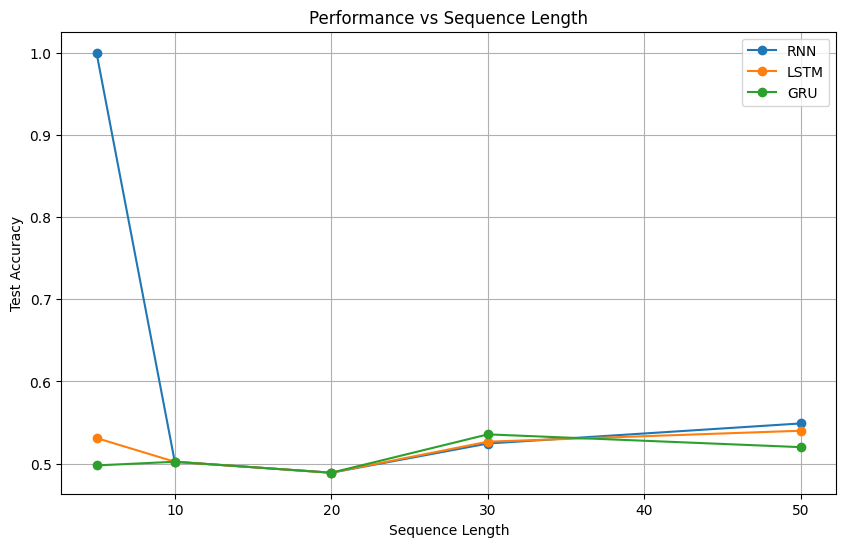

In [80]:
plt.figure(figsize=(10, 6))

plt.plot(
    SEQUENCE_LENGTHS,
    sequence_results["RNN"],
    marker="o",
    label="RNN"
)

plt.plot(
    SEQUENCE_LENGTHS,
    sequence_results["LSTM"],
    marker="o",
    label="LSTM"
)

plt.plot(
    SEQUENCE_LENGTHS,
    sequence_results["GRU"],
    marker="o",
    label="GRU"
)

plt.xlabel("Sequence Length")
plt.ylabel("Test Accuracy")
plt.title("Performance vs Sequence Length")

plt.legend()
plt.grid(True)

plt.show()

In [81]:
# gradient analysis
def rnn_gradient_by_timestep(X_batch, Y_batch, parameters):
    
    X_model = to_model_format(X_batch)
    
    n_x, m, T_x = X_model.shape
    n_a = parameters["Waa"].shape[0]
    
    a0 = np.zeros((n_a, m))
    
    a, y_pred, caches = rnn_forward(
        X_model,
        a0,
        parameters
    )
    
    Y_one_hot = one_hot_encode(
        Y_batch,
        num_classes=2
    )
    
    y_final = y_pred[:, :, -1]
    
    dz = y_final - Y_one_hot
    
    da_final = np.dot(
        parameters["Wya"].T,
        dz
    )
    
    gradient_norms = np.zeros(T_x)
    
    da_next = np.zeros((n_a, m))
    
    for t in reversed(range(T_x)):
        
        if t == T_x - 1:
            da_current = da_final
        else:
            da_current = np.zeros_like(da_final)
        
        gradients = rnn_cell_backward(
            da_current + da_next,
            caches[0][t]
        )
        
        da_next = gradients["da_prev"]
        
        gradient_norms[t] = np.mean(
            np.linalg.norm(
                da_next,
                axis=0
            )
        )
    
    return gradient_norms

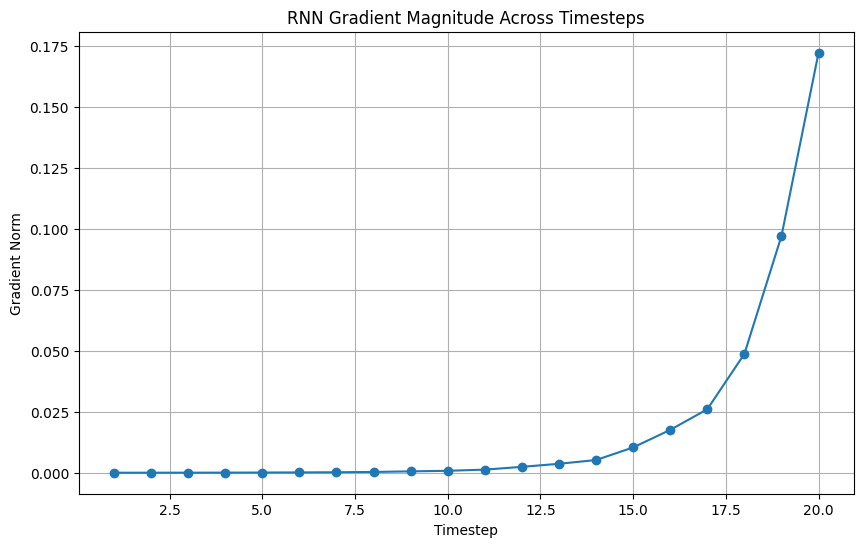

In [82]:
gradient_norms = rnn_gradient_by_timestep(
    X_test[:32],
    Y_test[:32],
    rnn_parameters
)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, SEQ_LENGTH + 1),
    gradient_norms,
    marker="o"
)

plt.xlabel("Timestep")
plt.ylabel("Gradient Norm")
plt.title("RNN Gradient Magnitude Across Timesteps")

plt.grid(True)

plt.show()

In [83]:
def get_rnn_hidden_states(X, parameters):
    
    X_model = to_model_format(X)
    
    m = X.shape[0]
    n_a = parameters["Waa"].shape[0]
    
    a0 = np.zeros((n_a, m))
    
    a, _, _ = rnn_forward(
        X_model,
        a0,
        parameters
    )
    
    return a

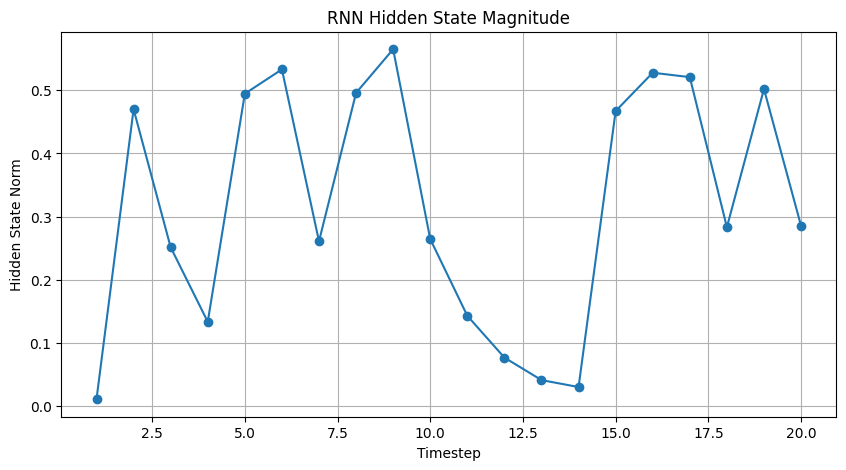

In [84]:
X_visual = X_test[:1]

rnn_hidden = get_rnn_hidden_states(
    X_visual,
    rnn_parameters
)

hidden_norms = np.linalg.norm(
    rnn_hidden[:, 0, :],
    axis=0
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, SEQ_LENGTH + 1),
    hidden_norms,
    marker="o"
)

plt.xlabel("Timestep")
plt.ylabel("Hidden State Norm")
plt.title("RNN Hidden State Magnitude")

plt.grid(True)

plt.show()

In [85]:
print("=" * 70)
print("STAGE 3 SUMMARY")
print("=" * 70)

print("\nTest Performance")
print("-" * 40)

print(
    f"RNN  : loss={rnn_test_loss:.4f}, "
    f"accuracy={rnn_test_acc:.4f}"
)

print(
    f"LSTM : loss={lstm_test_loss:.4f}, "
    f"accuracy={lstm_test_acc:.4f}"
)

print(
    f"GRU  : loss={gru_test_loss:.4f}, "
    f"accuracy={gru_test_acc:.4f}"
)

print("\nParameter Count")
print("-" * 40)

print(f"RNN  : {rnn_params:,}")
print(f"LSTM : {lstm_params:,}")
print(f"GRU  : {gru_params:,}")

print("\nSequence Lengths Tested")
print("-" * 40)

print(SEQUENCE_LENGTHS)

print("\nStage 3 investigation complete.")

STAGE 3 SUMMARY

Test Performance
----------------------------------------
RNN  : loss=0.6937, accuracy=0.4833
LSTM : loss=0.6937, accuracy=0.4922
GRU  : loss=0.6940, accuracy=0.4811

Parameter Count
----------------------------------------
RNN  : 1,154
LSTM : 4,418
GRU  : 3,330

Sequence Lengths Tested
----------------------------------------
[5, 10, 20, 30, 50]

Stage 3 investigation complete.


# Internals, Gates & Analysis

In [86]:
# Select one test example

sample_index = 0

X_one = X_test[sample_index:sample_index + 1]
Y_one = Y_test[sample_index:sample_index + 1]

print("Input sequence:")
print(X_one[0, :, 0].astype(int))

print("\nTarget:")
print(int(Y_one[0, 0]))

Input sequence:
[0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 1 1 0 1 0]

Target:
0


In [87]:
def get_rnn_states(X, parameters):
    
    X_model = to_model_format(X)
    
    m = X.shape[0]
    n_a = parameters["Waa"].shape[0]
    
    a0 = np.zeros((n_a, m))
    
    a, y, caches = rnn_forward(
        X_model,
        a0,
        parameters
    )
    
    return a, y, caches

In [88]:
rnn_a, rnn_y, rnn_cache = get_rnn_states(
    X_one,
    rnn_parameters
)

print("RNN hidden-state shape:")
print(rnn_a.shape)

print("\nExpected:")
print("(hidden_size, batch_size, sequence_length)")

RNN hidden-state shape:
(32, 1, 20)

Expected:
(hidden_size, batch_size, sequence_length)


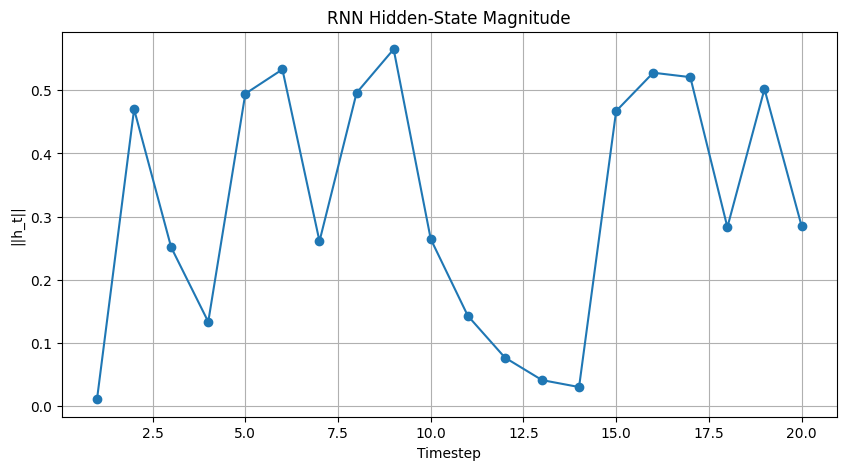

In [89]:
rnn_state_norm = np.linalg.norm(
    rnn_a[:, 0, :],
    axis=0
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, SEQ_LENGTH + 1),
    rnn_state_norm,
    marker="o"
)

plt.xlabel("Timestep")
plt.ylabel("||h_t||")
plt.title("RNN Hidden-State Magnitude")

plt.grid(True)
plt.show()

In [90]:
# lstm internal states
def get_lstm_states(X, parameters):
    
    X_model = to_model_format(X)
    
    m = X.shape[0]
    n_a = parameters["Wf"].shape[0]
    
    a0 = np.zeros((n_a, m))
    
    a, y, c, caches = lstm_forward(
        X_model,
        a0,
        parameters
    )
    
    return a, c, y, caches

In [91]:
lstm_a, lstm_c, lstm_y, lstm_cache = get_lstm_states(
    X_one,
    lstm_parameters
)

print("LSTM hidden-state shape:")
print(lstm_a.shape)

print("\nLSTM cell-state shape:")
print(lstm_c.shape)

LSTM hidden-state shape:
(32, 1, 20)

LSTM cell-state shape:
(32, 1, 20)


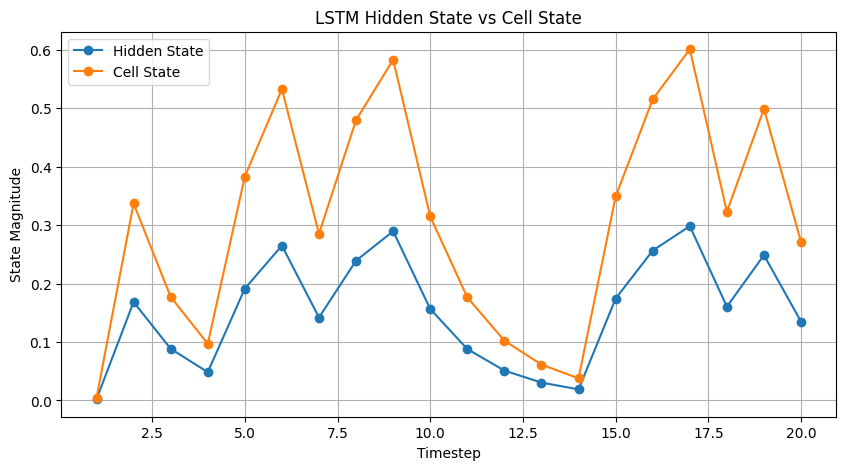

In [92]:
# compare lstm hidden state and cell state
lstm_hidden_norm = np.linalg.norm(
    lstm_a[:, 0, :],
    axis=0
)

lstm_cell_norm = np.linalg.norm(
    lstm_c[:, 0, :],
    axis=0
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, SEQ_LENGTH + 1),
    lstm_hidden_norm,
    marker="o",
    label="Hidden State"
)

plt.plot(
    range(1, SEQ_LENGTH + 1),
    lstm_cell_norm,
    marker="o",
    label="Cell State"
)

plt.xlabel("Timestep")
plt.ylabel("State Magnitude")
plt.title("LSTM Hidden State vs Cell State")

plt.legend()
plt.grid(True)

plt.show()

In [93]:
def extract_lstm_gates(lstm_cache):
    
    caches, x = lstm_cache
    
    forget_values = []
    input_values = []
    output_values = []
    candidate_values = []
    
    for cache in caches:
        
        (
            a_next,
            c_next,
            a_prev,
            c_prev,
            ft,
            it,
            cct,
            ot,
            xt,
            parameters
        ) = cache
        
        forget_values.append(
            np.mean(ft[:, 0])
        )
        
        input_values.append(
            np.mean(it[:, 0])
        )
        
        output_values.append(
            np.mean(ot[:, 0])
        )
        
        candidate_values.append(
            np.mean(cct[:, 0])
        )
    
    return (
        np.array(forget_values),
        np.array(input_values),
        np.array(output_values),
        np.array(candidate_values)
    )

In [94]:
(
    forget_values,
    input_values,
    output_values,
    candidate_values
) = extract_lstm_gates(
    lstm_cache
)

print("Forget gate:")
print(forget_values)

print("\nInput gate:")
print(input_values)

print("\nOutput gate:")
print(output_values)

Forget gate:
[0.50000324 0.49508141 0.50014751 0.50002662 0.4950657  0.49520839
 0.5001855  0.4950938  0.49520841 0.50017636 0.50000217 0.49995309
 0.49994898 0.49995987 0.49505125 0.49520849 0.49526959 0.50020924
 0.49509619 0.50012692]

Input gate:
[0.50001308 0.49844969 0.49874555 0.49939371 0.49816103 0.49704873
 0.49808378 0.49751901 0.49675492 0.49795314 0.49902921 0.49956616
 0.49982014 0.49993659 0.49841955 0.49716396 0.49656953 0.49786217
 0.49741705 0.49827326]

Output gate:
[0.50001182 0.49596776 0.4999429  0.50000675 0.49596131 0.49588858
 0.49991799 0.4959577  0.49586691 0.49989464 0.49997735 0.49996759
 0.49996393 0.4999673  0.49593709 0.49588375 0.49588514 0.49991803
 0.49595611 0.49989446]


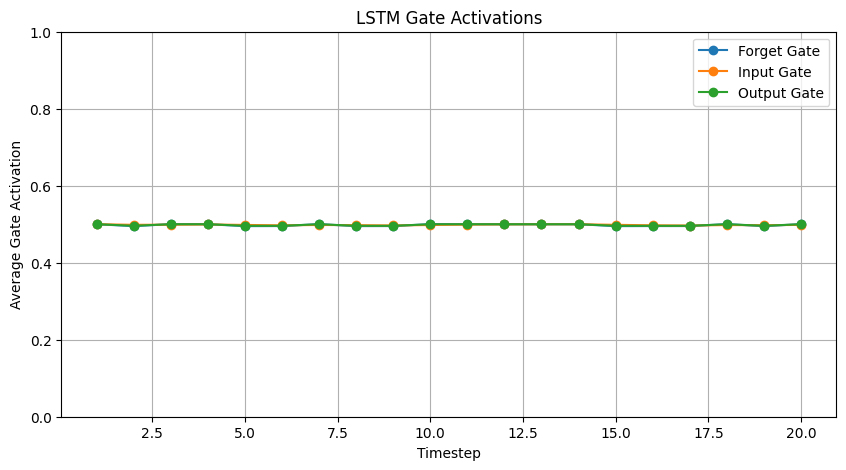

In [95]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, SEQ_LENGTH + 1),
    forget_values,
    marker="o",
    label="Forget Gate"
)

plt.plot(
    range(1, SEQ_LENGTH + 1),
    input_values,
    marker="o",
    label="Input Gate"
)

plt.plot(
    range(1, SEQ_LENGTH + 1),
    output_values,
    marker="o",
    label="Output Gate"
)

plt.xlabel("Timestep")
plt.ylabel("Average Gate Activation")
plt.title("LSTM Gate Activations")

plt.ylim(0, 1)

plt.legend()
plt.grid(True)

plt.show()

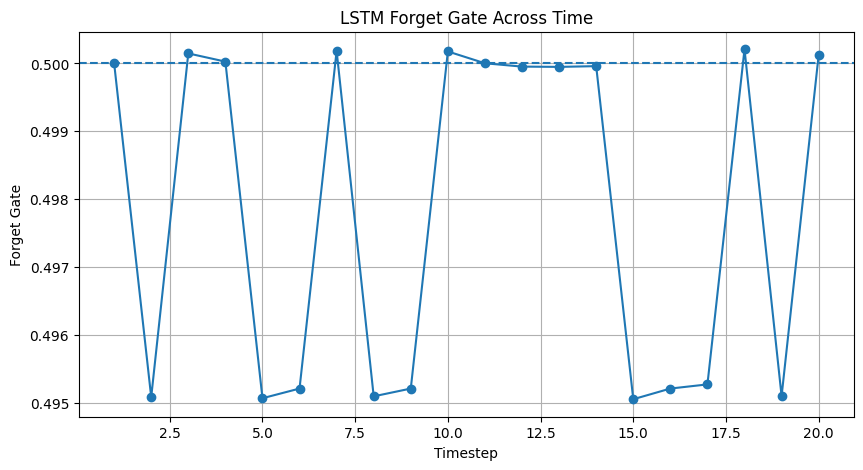

In [96]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, SEQ_LENGTH + 1),
    forget_values,
    marker="o"
)

plt.axhline(
    0.5,
    linestyle="--"
)

plt.xlabel("Timestep")
plt.ylabel("Forget Gate")
plt.title("LSTM Forget Gate Across Time")

plt.grid(True)

plt.show()

# GRU internal state

In [97]:
def get_gru_states(X, parameters):
    
    X_model = to_model_format(X)
    
    m = X.shape[0]
    n_a = parameters["Wz"].shape[0]
    
    a0 = np.zeros((n_a, m))
    
    a, y, caches = gru_forward(
        X_model,
        a0,
        parameters
    )
    
    return a, y, caches

In [98]:
gru_a, gru_y, gru_cache = get_gru_states(
    X_one,
    gru_parameters
)

print("GRU hidden-state shape:")
print(gru_a.shape)

GRU hidden-state shape:
(32, 1, 20)


In [99]:
def extract_gru_gates(gru_cache):
    
    caches, x = gru_cache
    
    update_values = []
    reset_values = []
    
    for cache in caches:
        
        (
            a_next,
            a_prev,
            zt,
            rt,
            a_candidate,
            xt,
            parameters
        ) = cache
        
        update_values.append(
            np.mean(zt[:, 0])
        )
        
        reset_values.append(
            np.mean(rt[:, 0])
        )
    
    return (
        np.array(update_values),
        np.array(reset_values)
    )

In [100]:
(
    update_values,
    reset_values
) = extract_gru_gates(
    gru_cache
)

print("Update gate:")
print(update_values)

print("\nReset gate:")
print(reset_values)

Update gate:
[0.50002876 0.49513332 0.50044047 0.50015178 0.49512625 0.49544158
 0.50033322 0.49508084 0.49527687 0.5001716  0.49989635 0.49985177
 0.49989332 0.49995519 0.49508039 0.49547261 0.49544999 0.50024912
 0.49500731 0.50013837]

Reset gate:
[0.50000493 0.49840832 0.49800753 0.4990265  0.49796168 0.49623439
 0.49692467 0.49695102 0.4957512  0.49669052 0.49841062 0.4992583
 0.49965173 0.49982538 0.49832675 0.49639929 0.49544157 0.4965262
 0.49676395 0.4972225 ]


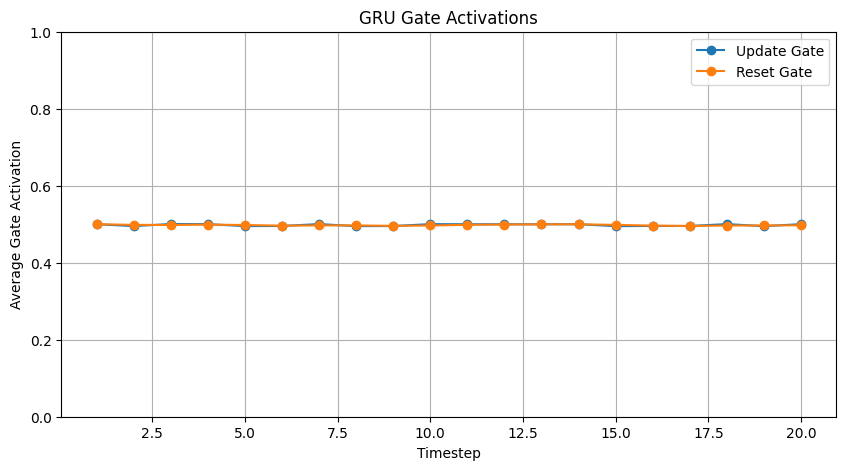

In [101]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, SEQ_LENGTH + 1),
    update_values,
    marker="o",
    label="Update Gate"
)

plt.plot(
    range(1, SEQ_LENGTH + 1),
    reset_values,
    marker="o",
    label="Reset Gate"
)

plt.xlabel("Timestep")
plt.ylabel("Average Gate Activation")
plt.title("GRU Gate Activations")

plt.ylim(0, 1)

plt.legend()
plt.grid(True)

plt.show()

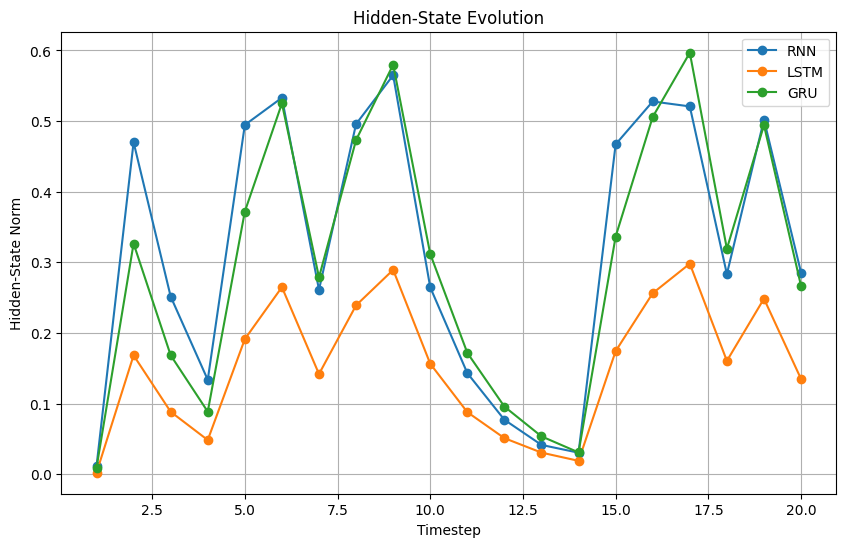

In [102]:
rnn_norm = np.linalg.norm(
    rnn_a[:, 0, :],
    axis=0
)

lstm_norm = np.linalg.norm(
    lstm_a[:, 0, :],
    axis=0
)

gru_norm = np.linalg.norm(
    gru_a[:, 0, :],
    axis=0
)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, SEQ_LENGTH + 1),
    rnn_norm,
    marker="o",
    label="RNN"
)

plt.plot(
    range(1, SEQ_LENGTH + 1),
    lstm_norm,
    marker="o",
    label="LSTM"
)

plt.plot(
    range(1, SEQ_LENGTH + 1),
    gru_norm,
    marker="o",
    label="GRU"
)

plt.xlabel("Timestep")
plt.ylabel("Hidden-State Norm")
plt.title("Hidden-State Evolution")

plt.legend()
plt.grid(True)

plt.show()

In [103]:
rnn_final = rnn_y[:, 0, -1]
lstm_final = lstm_y[:, 0, -1]
gru_final = gru_y[:, 0, -1]

target = int(Y_one[0, 0])

print("Sequence:")
print(X_one[0, :, 0].astype(int))

print("\nTarget:", target)

print("\nFinal predictions:")
print(
    f"RNN  → class {np.argmax(rnn_final)}, "
    f"P(class 1) = {rnn_final[1]:.4f}"
)

print(
    f"LSTM → class {np.argmax(lstm_final)}, "
    f"P(class 1) = {lstm_final[1]:.4f}"
)

print(
    f"GRU  → class {np.argmax(gru_final)}, "
    f"P(class 1) = {gru_final[1]:.4f}"
)

Sequence:
[0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 1 1 0 1 0]

Target: 0

Final predictions:
RNN  → class 0, P(class 1) = 0.4882
LSTM → class 0, P(class 1) = 0.4947
GRU  → class 0, P(class 1) = 0.4960


In [104]:
print("=" * 60)
print("PARAMETER COMPARISON")
print("=" * 60)

print(f"RNN  : {rnn_params:,}")
print(f"LSTM : {lstm_params:,}")
print(f"GRU  : {gru_params:,}")

print()

print("Relative to RNN:")

print(
    f"LSTM / RNN = {lstm_params / rnn_params:.2f}x"
)

print(
    f"GRU / RNN  = {gru_params / rnn_params:.2f}x"
)

PARAMETER COMPARISON
RNN  : 1,154
LSTM : 4,418
GRU  : 3,330

Relative to RNN:
LSTM / RNN = 3.83x
GRU / RNN  = 2.89x


In [105]:
print("=" * 90)
print(
    f"{'Model':<10}"
    f"{'Parameters':<15}"
    f"{'Test Loss':<15}"
    f"{'Test Accuracy':<15}"
)
print("=" * 90)

print(
    f"{'RNN':<10}"
    f"{rnn_params:<15,}"
    f"{rnn_test_loss:<15.4f}"
    f"{rnn_test_acc:<15.4f}"
)

print(
    f"{'LSTM':<10}"
    f"{lstm_params:<15,}"
    f"{lstm_test_loss:<15.4f}"
    f"{lstm_test_acc:<15.4f}"
)

print(
    f"{'GRU':<10}"
    f"{gru_params:<15,}"
    f"{gru_test_loss:<15.4f}"
    f"{gru_test_acc:<15.4f}"
)

print("=" * 90)

Model     Parameters     Test Loss      Test Accuracy  
RNN       1,154          0.6937         0.4833         
LSTM      4,418          0.6937         0.4922         
GRU       3,330          0.6940         0.4811         
